# Interpretable Heart Disease Risk Prediction

This notebook presents a recruiter-focused machine learning case study: predicting heart disease presence from structured patient health data while keeping the workflow interpretable, practical, and easy to explain.

The goal is **risk screening**, not diagnosis. A model like this should help prioritize attention and support clinicians, never replace clinical judgment.

**Project highlights**

- Clean preprocessing with missing-value handling
- Logistic Regression and Random Forest models
- Cross-validation and lightweight hyperparameter tuning
- ROC-AUC, classification reports, confusion matrices, and threshold analysis
- Random Forest feature importance and SHAP explanations
- Real-world healthcare deployment discussion

## 1. Data Understanding

Before modeling, we inspect the dataset structure, missing values, data types, and summary statistics. This keeps the modeling choices grounded in the actual data rather than assumptions.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = Path("data") / "heart_disease_uci.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_PATH = Path("model.pkl")
TUNED_MODEL_PATH = Path("tuned_model.pkl")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

TARGET_PALETTE = {"No disease": "#2A9D8F", "Disease present": "#E76F51"}
MODEL_COLORS = {
    "Logistic Regression": "#264653",
    "Random Forest": "#2A9D8F",
    "Tuned Random Forest": "#E76F51",
}

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset shape: 920 rows x 16 columns

Column names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [5]:
missing_values = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: (x["missing_count"] / len(df) * 100).round(1))
    .sort_values("missing_count", ascending=False)
)
missing_values

,missing_count,missing_percent
ca,611,66.4
thal,486,52.8
slope,309,33.6
fbs,90,9.8
oldpeak,62,6.7
trestbps,59,6.4
exang,55,6.0
thalch,55,6.0
chol,30,3.3
restecg,2,0.2


The dataset contains several missing values, especially in `ca`, `thal`, and `slope`. Dropping every incomplete row would discard too much information, so the workflow uses transparent imputation inside sklearn pipelines.

## 2. Preprocessing

The original `num` column stores disease severity from 0 to 4. For this project, the target is converted to a binary classification task:

- `0`: no heart disease
- `1`: heart disease present (`num > 0`)

Preprocessing decisions:

- Remove `id` because it is only an identifier.
- Remove `dataset` because it identifies collection source rather than patient health data.
- Median-impute numeric features.
- Mode-impute categorical features.
- One-hot encode categorical variables.
- Scale numeric features for Logistic Regression.

These steps are placed inside sklearn Pipelines to reduce data leakage and make the workflow more production-like.

In [6]:
y = (df["num"] > 0).astype(int)
X = df.drop(columns=["id", "dataset", "num"])

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("\nTarget distribution:")
print(y.value_counts().rename({0: "No disease", 1: "Disease present"}))

Numeric features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Target distribution:
num
Disease present    509
No disease         411
Name: count, dtype: int64


In [7]:
def build_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        verbose_feature_names_out=False,
    )


logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)

## 3. Exploratory Data Analysis

The EDA focuses on clinically interpretable patterns. These visuals are descriptive, not causal.

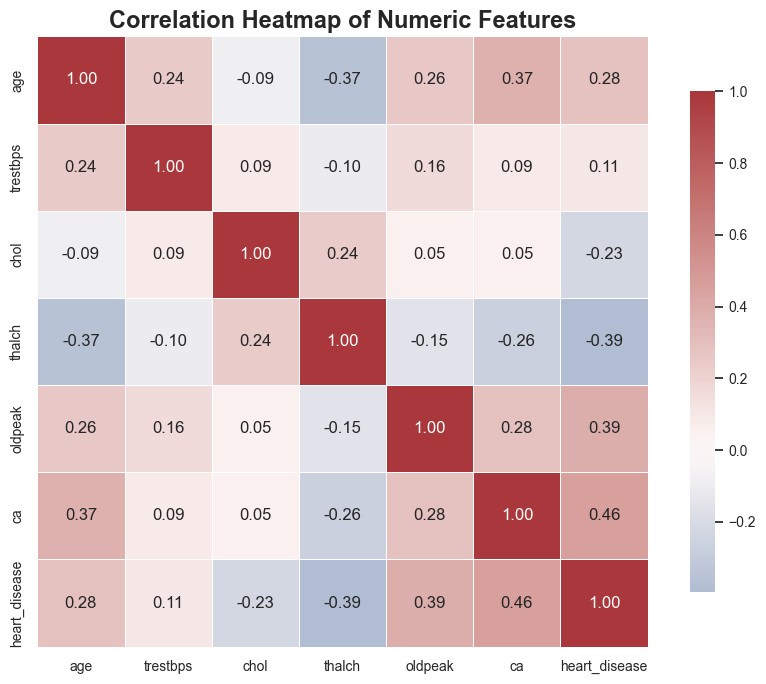

In [8]:
eda_df = df.copy()
eda_df["heart_disease"] = y.map({0: "No disease", 1: "Disease present"})

corr_df = df[numeric_features].copy()
corr_df["heart_disease"] = y
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={"shrink": 0.82},
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

`oldpeak`, `thalch`, and `age` show meaningful relationships with the target. This supports choosing interpretable models that can use both linear patterns and nonlinear interactions.

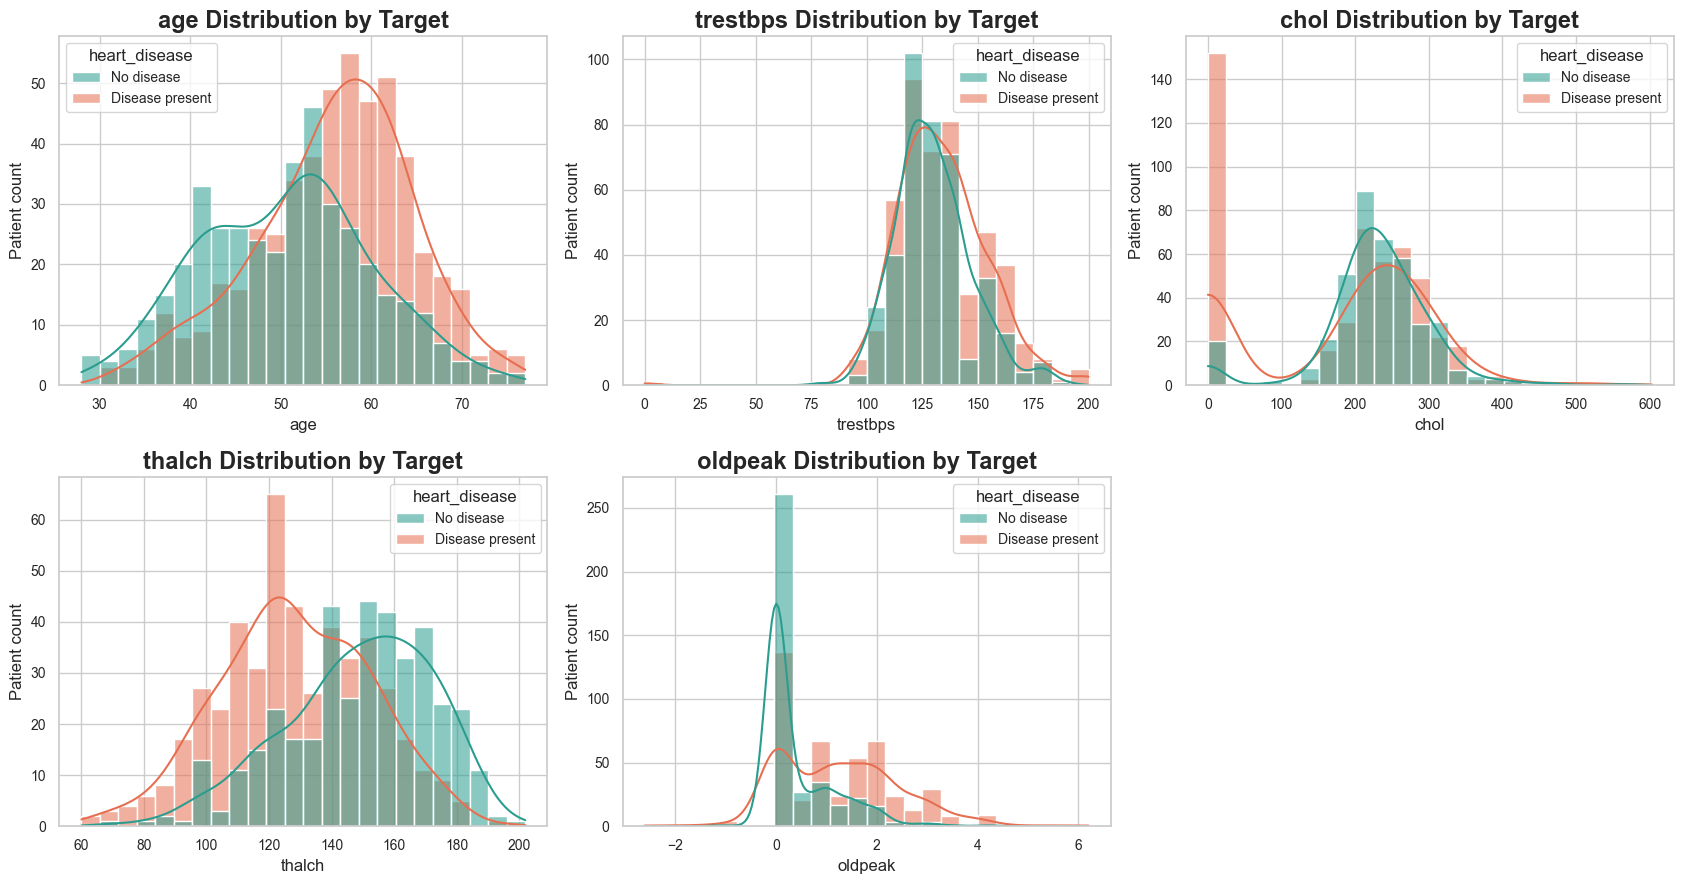

In [9]:
key_numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for ax, column in zip(axes, key_numeric_features):
    sns.histplot(
        data=eda_df,
        x=column,
        hue="heart_disease",
        kde=True,
        bins=24,
        palette=TARGET_PALETTE,
        alpha=0.55,
        ax=ax,
    )
    ax.set_title(f"{column} Distribution by Target")
    ax.set_xlabel(column)
    ax.set_ylabel("Patient count")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

The clearest separation appears around maximum heart rate (`thalch`) and ST depression (`oldpeak`). Cholesterol and resting blood pressure are useful but noisier as standalone indicators.

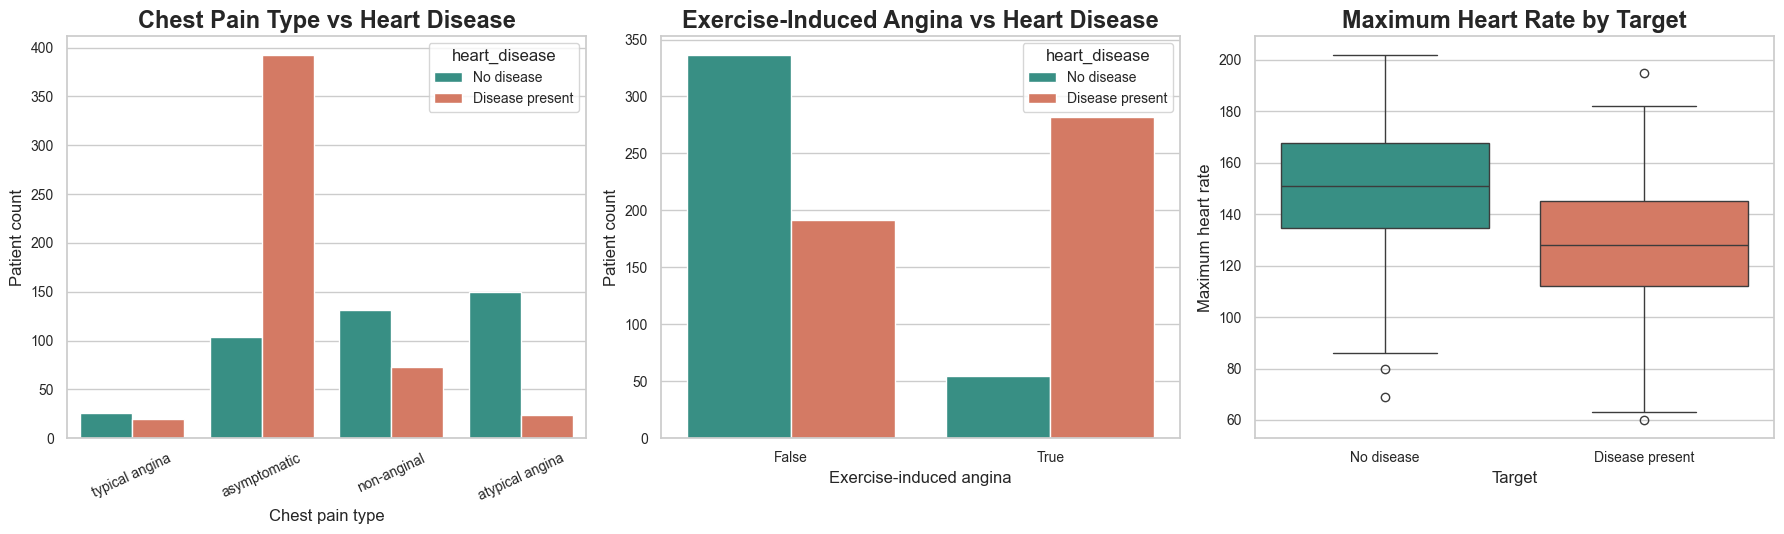

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

sns.countplot(data=eda_df, x="cp", hue="heart_disease", palette=TARGET_PALETTE, ax=axes[0])
axes[0].set_title("Chest Pain Type vs Heart Disease")
axes[0].set_xlabel("Chest pain type")
axes[0].set_ylabel("Patient count")
axes[0].tick_params(axis="x", rotation=25)

sns.countplot(data=eda_df, x="exang", hue="heart_disease", palette=TARGET_PALETTE, ax=axes[1])
axes[1].set_title("Exercise-Induced Angina vs Heart Disease")
axes[1].set_xlabel("Exercise-induced angina")
axes[1].set_ylabel("Patient count")

sns.boxplot(data=eda_df, x="heart_disease", y="thalch", palette=TARGET_PALETTE, ax=axes[2])
axes[2].set_title("Maximum Heart Rate by Target")
axes[2].set_xlabel("Target")
axes[2].set_ylabel("Maximum heart rate")

plt.tight_layout()
plt.show()

Chest pain type, exercise-induced angina, and maximum heart rate show understandable differences between groups, making them useful features to inspect later with model interpretation.

## 4. Train-Test Split

A stratified 80/20 split keeps the disease/no-disease balance similar in both training and test data. The fixed random state makes results reproducible.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 736
Test rows: 184


## 5. Modeling

Two models are trained:

- **Logistic Regression**: a strong interpretable baseline that works well for structured tabular data.
- **Random Forest**: a tree ensemble that can capture nonlinear relationships and feature interactions.

In [12]:
logistic_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

print("Base models trained successfully.")

Base models trained successfully.


## 6. Hyperparameter Tuning

Hyperparameter tuning searches over model settings that are not learned directly from the data. The grid is intentionally small so the project remains fast, readable, and reproducible.

Overfitting matters because a model can memorize training patterns that do not generalize to future patients.

In [13]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [3, 5],
}

tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
rf_search = GridSearchCV(
    random_forest_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=tuning_cv,
    n_jobs=1,
)
rf_search.fit(X_train, y_train)

tuned_random_forest = rf_search.best_estimator_

print("Best parameters:", rf_search.best_params_)
print(f"Best cross-validated F1: {rf_search.best_score_:.3f}")

Best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Best cross-validated F1: 0.846


## 7. Evaluation

This section evaluates performance on the held-out test set. In healthcare screening, recall is especially important because a false negative means a patient with possible disease is missed.

In [14]:
def evaluate_model(name, model):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
    }


models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Tuned Random Forest": tuned_random_forest,
}

results = pd.DataFrame([evaluate_model(name, model) for name, model in models.items()])
results.round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.842,0.841,0.882,0.861,0.902
1,Random Forest,0.842,0.841,0.882,0.861,0.913
2,Tuned Random Forest,0.848,0.849,0.882,0.865,0.915


The tuned Random Forest slightly improves F1 and ROC-AUC. Logistic Regression remains valuable because it is simpler to explain, while Random Forest provides stronger nonlinear interpretation through feature importance and SHAP.

In [15]:
report_tables = []

for name, model in models.items():
    report = classification_report(
        y_test,
        model.predict(X_test),
        target_names=["No disease", "Disease"],
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    report_df.insert(0, "model", name)
    report_tables.append(report_df)

classification_reports = pd.concat(report_tables)
classification_reports.round(3)

,model,precision,recall,f1-score,support
No disease,Logistic Regression,0.844,0.793,0.818,82.000
Disease,Logistic Regression,0.841,0.882,0.861,102.000
accuracy,Logistic Regression,0.842,0.842,0.842,0.842
macro avg,Logistic Regression,0.843,0.838,0.839,184.000
weighted avg,Logistic Regression,0.842,0.842,0.842,184.000
No disease,Random Forest,0.844,0.793,0.818,82.000
Disease,Random Forest,0.841,0.882,0.861,102.000
accuracy,Random Forest,0.842,0.842,0.842,0.842
macro avg,Random Forest,0.843,0.838,0.839,184.000
weighted avg,Random Forest,0.842,0.842,0.842,184.000


Classification reports show precision, recall, F1-score, and support for each class. The dataset is not perfectly balanced: there are more positive disease cases than no-disease cases. Reporting class-level metrics avoids hiding this behind accuracy alone.

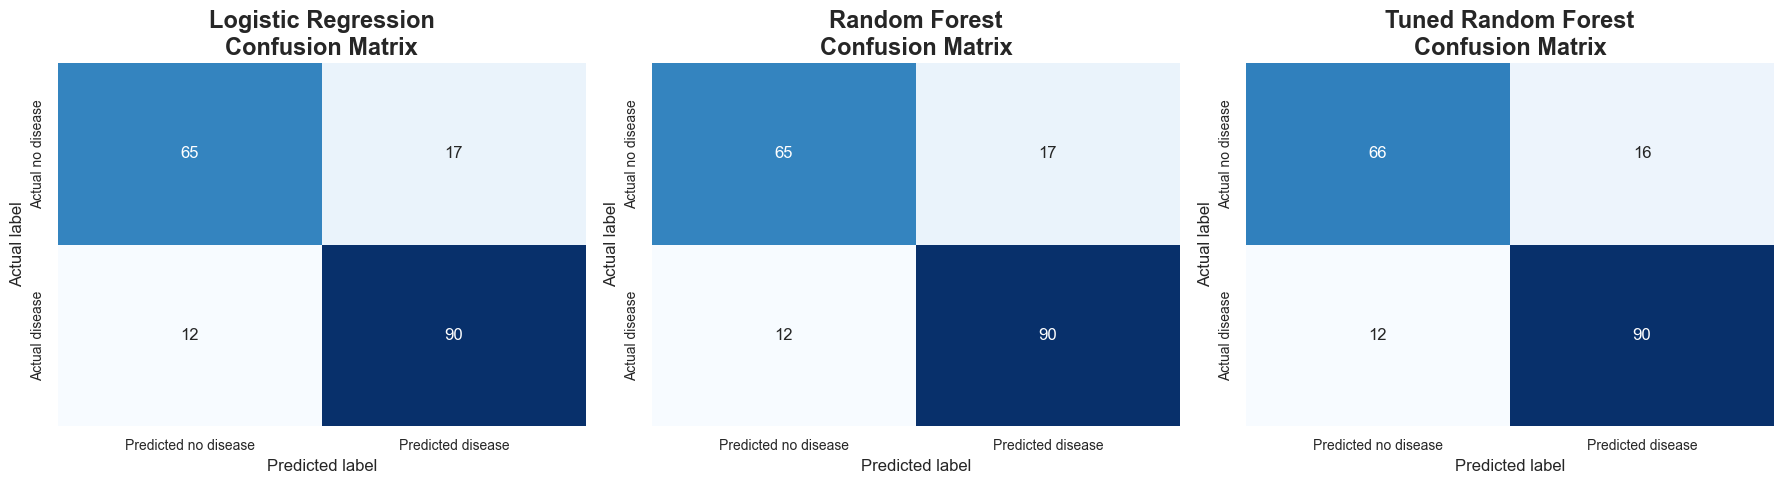

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    matrix = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted no disease", "Predicted disease"],
        yticklabels=["Actual no disease", "Actual disease"],
        ax=ax,
    )
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")

plt.tight_layout()
plt.show()

A false positive means a patient is flagged as higher risk when they may not have disease. A false negative means the model misses a patient who may have disease. In screening contexts, false negatives are often more costly because they can delay care.

## 8. ROC Curve and ROC-AUC

The ROC curve shows the tradeoff between true positive rate and false positive rate across many classification thresholds. ROC-AUC summarizes that curve into one number: higher values indicate better separation between the two classes.

ROC-AUC is useful in healthcare classification because the decision threshold may change depending on clinical context. A screening workflow may prefer higher recall, while a follow-up testing workflow may require higher precision.

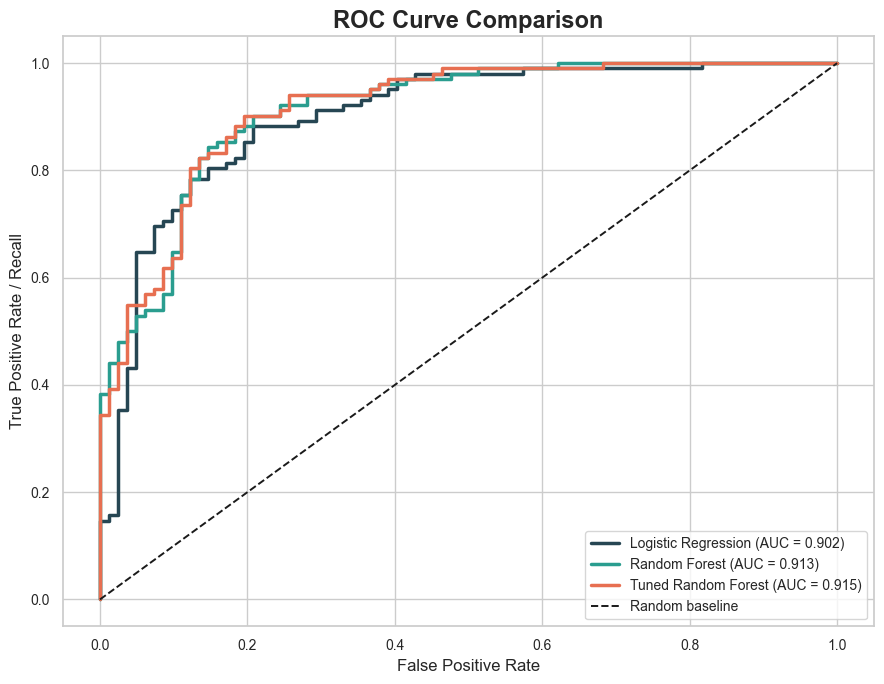

Logistic Regression    0.902
Random Forest          0.913
Tuned Random Forest    0.915
Name: ROC-AUC, dtype: float64

In [17]:
plt.figure(figsize=(9, 7))
auc_scores = {}

for name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)
    auc_scores[name] = auc_score
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2.5,
        color=MODEL_COLORS[name],
        label=f"{name} (AUC = {auc_score:.3f})",
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1.4, label="Random baseline")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=180, bbox_inches="tight")
plt.show()

pd.Series(auc_scores, name="ROC-AUC").round(3)

## 9. Cross-Validation

A single train-test split can be lucky or unlucky. Stratified cross-validation evaluates models across multiple splits while preserving class balance, giving a more stable estimate of model behavior.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
}.items():
    row = {"model": name}
    for metric_name, scoring in {"accuracy": "accuracy", "recall": "recall", "f1": "f1"}.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
        row[f"mean_{metric_name}"] = scores.mean()
        row[f"std_{metric_name}"] = scores.std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows)
cv_results.round(3)

,model,mean_accuracy,std_accuracy,mean_recall,std_recall,mean_f1,std_f1
0,Logistic Regression,0.826,0.031,0.855,0.056,0.844,0.032
1,Random Forest,0.823,0.032,0.857,0.052,0.842,0.031


Cross-validation confirms that performance is reasonably stable, with recall remaining strong across folds. This is more reassuring than relying only on one held-out split.

## 10. Feature Importance

Random Forest feature importance provides a quick view of which variables the model uses most often for splitting decisions. It is useful, but it does not show direction or patient-level impact.

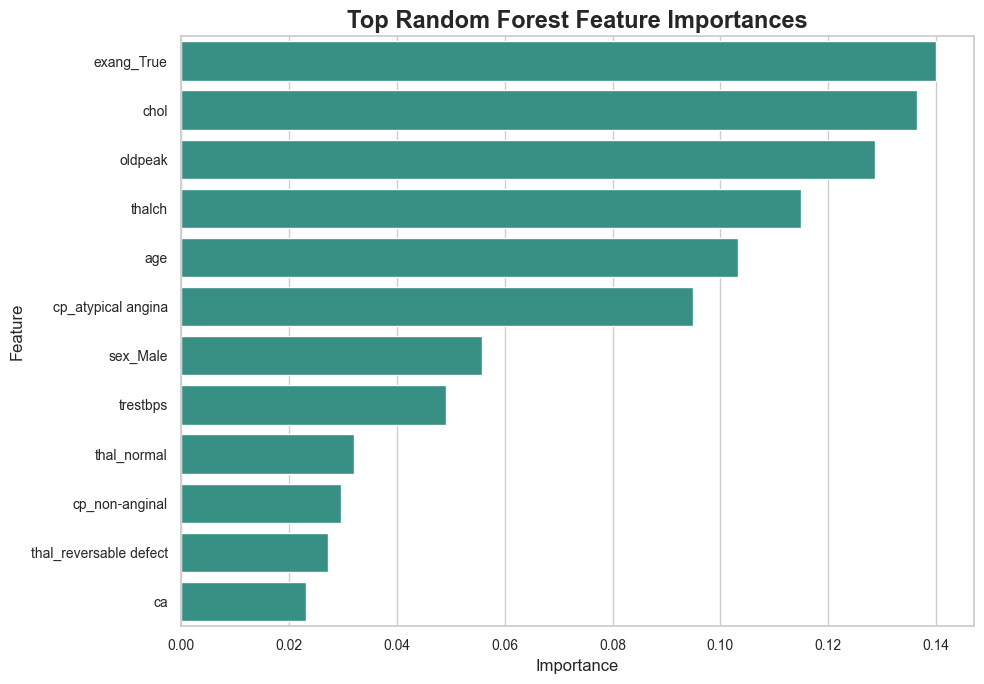

,feature,importance
13,exang_True,0.139996
2,chol,0.136394
4,oldpeak,0.128722
3,thalch,0.115013
0,age,0.103310
7,cp_atypical angina,0.094877
6,sex_Male,0.055781
1,trestbps,0.049075
16,thal_normal,0.032032
8,cp_non-anginal,0.029764


In [19]:
def transformed_feature_matrix(model, raw_X):
    preprocessor = model.named_steps["preprocessor"]
    transformed = preprocessor.transform(raw_X)
    feature_names = preprocessor.get_feature_names_out()
    return pd.DataFrame(transformed, columns=feature_names, index=raw_X.index)


X_test_transformed = transformed_feature_matrix(tuned_random_forest, X_test)
rf_model = tuned_random_forest.named_steps["model"]

importance_df = (
    pd.DataFrame({
        "feature": X_test_transformed.columns,
        "importance": rf_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, y="feature", x="importance", color="#2A9D8F")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df

The most important features are medically plausible: exercise-induced angina, ST depression, cholesterol, chest pain type, age, and maximum heart rate all relate to cardiovascular stress or symptoms.

## 11. SHAP Interpretability

SHAP values estimate how much each feature pushes an individual prediction higher or lower compared with the model's baseline prediction.

Difference from feature importance:

- Random Forest importance ranks features by how often they improve tree splits.
- SHAP explains the direction and magnitude of feature impact on predictions.

This matters in healthcare AI because model users need to understand why a patient was flagged, especially when false positives and false negatives have real consequences.

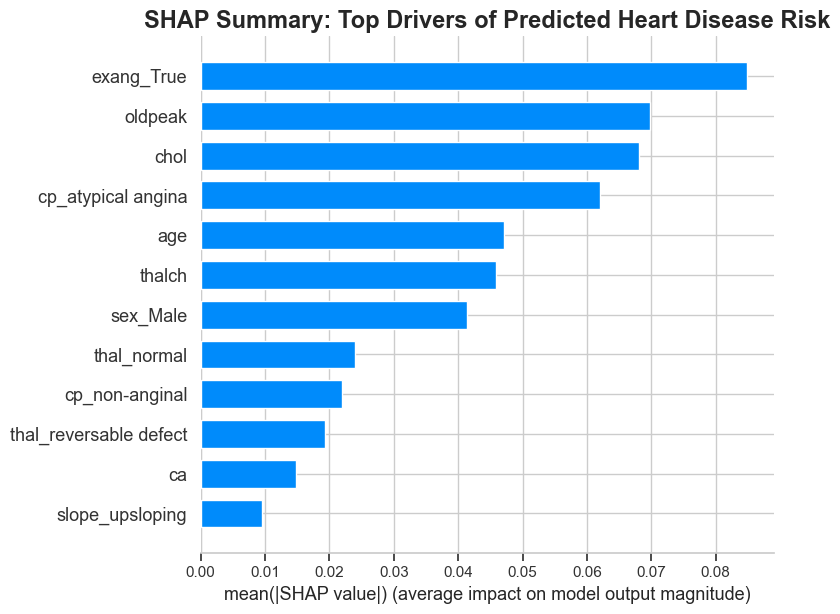

,feature,mean_abs_shap
0,exang_True,0.084815
1,oldpeak,0.069746
2,chol,0.068036
3,cp_atypical angina,0.062015
4,age,0.047143
5,thalch,0.045813
6,sex_Male,0.041388
7,thal_normal,0.023940
8,cp_non-anginal,0.022008
9,thal_reversable defect,0.019308


In [20]:
def positive_class_shap_values(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    if getattr(shap_values, "ndim", 0) == 3:
        return shap_values[:, :, 1]
    return shap_values


X_shap = X_test_transformed.sample(min(150, len(X_test_transformed)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(rf_model)
shap_values = positive_class_shap_values(explainer.shap_values(X_shap))

shap_importance = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=12, show=False)
plt.title("SHAP Summary: Top Drivers of Predicted Heart Disease Risk")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", dpi=180, bbox_inches="tight")
plt.show()

shap_importance.head(12)

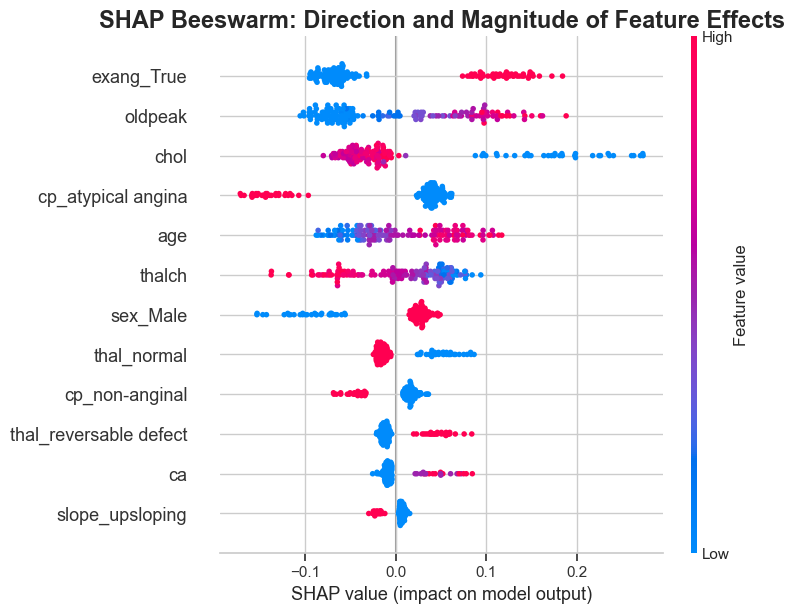

In [21]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, max_display=12, show=False)
plt.title("SHAP Beeswarm: Direction and Magnitude of Feature Effects")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm.png", dpi=180, bbox_inches="tight")
plt.show()

In the beeswarm plot, points to the right increase predicted heart disease risk and points to the left lower it. Red points represent higher feature values. For binary encoded features such as `exang_True`, a value of 1 means the condition is present. The SHAP results reinforce that exercise-induced angina, ST depression, cholesterol, chest pain type, age, and maximum heart rate are major model drivers.

## 12. Threshold Analysis

The default classification threshold is 0.50. In healthcare screening, threshold choice is a product decision as much as a modeling decision because it controls the balance between missed cases and false alarms.

In [22]:
rf_probabilities = tuned_random_forest.predict_proba(X_test)[:, 1]
threshold_rows = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_predictions = (rf_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, threshold_predictions, zero_division=0),
        "recall": recall_score(y_test, threshold_predictions, zero_division=0),
        "f1": f1_score(y_test, threshold_predictions, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.round(3)

,threshold,precision,recall,f1
0,0.3,0.758,0.951,0.843
1,0.4,0.816,0.912,0.861
2,0.5,0.849,0.882,0.865
3,0.6,0.875,0.824,0.848
4,0.7,0.882,0.657,0.753


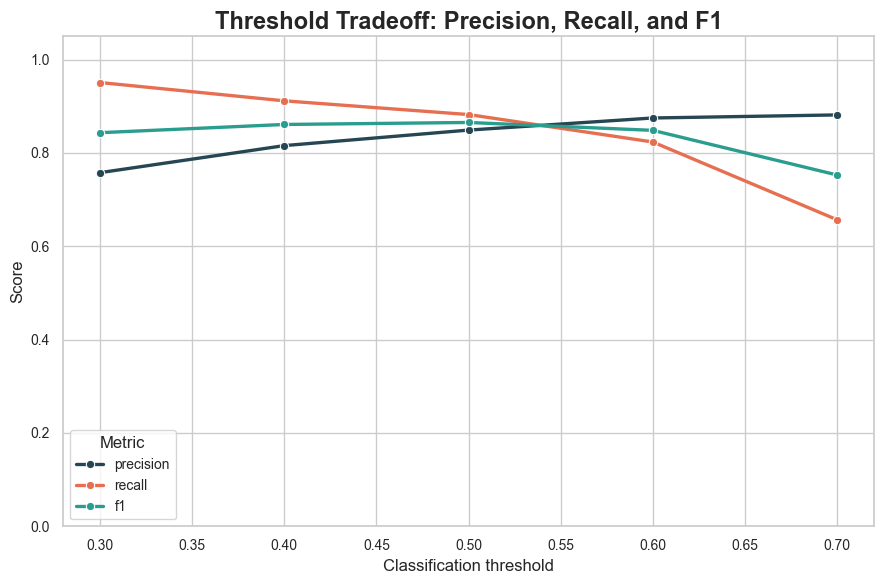

In [23]:
threshold_long = threshold_df.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(9, 6))
sns.lineplot(
    data=threshold_long,
    x="threshold",
    y="score",
    hue="metric",
    marker="o",
    linewidth=2.4,
    palette=["#264653", "#E76F51", "#2A9D8F"],
)
plt.title("Threshold Tradeoff: Precision, Recall, and F1")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

Lower thresholds catch more disease cases and increase recall, but they also increase false positives. Higher thresholds reduce false alarms but miss more true disease cases. For screening, a lower threshold may be preferred if follow-up testing is available.

## 13. Key Insights

1. The model's strongest signals are clinically interpretable: exercise-induced angina, ST depression, cholesterol, chest pain type, age, and maximum heart rate.
2. ROC-AUC above 0.90 suggests the models separate disease and no-disease cases well on this held-out split.
3. Logistic Regression is an excellent explainable baseline; tuned Random Forest slightly improves overall performance and enables richer nonlinear interpretation.
4. Threshold tuning is critical because the best threshold depends on clinical workflow and tolerance for false alarms.
5. SHAP adds practical interpretability by showing both feature importance and direction of impact.

## 14. Real-World Deployment Considerations

A healthcare ML model should be deployed carefully and with clinical oversight.

- **Healthcare bias:** Data collected from limited hospitals or populations may underperform for other demographic groups.
- **False negatives:** Missing a true heart disease case can delay care, so recall must be monitored closely.
- **False positives:** Over-alerting can create anxiety, unnecessary testing, and clinician fatigue.
- **Data drift:** Patient populations, clinical practices, and measurement devices change over time.
- **Privacy:** Patient data requires strict privacy, security, and compliance controls.
- **Clinical oversight:** Predictions should support doctors and care teams rather than replace diagnosis.
- **Transparency:** Clinicians need interpretable outputs, not just risk labels.

## 15. Save Models and Artifacts

The final tuned Random Forest model is saved with its preprocessing pipeline so future predictions apply the same imputation, encoding, and model logic.

In [24]:
joblib.dump(
    {
        "model": random_forest_pipeline,
        "model_name": "Random Forest",
        "target_definition": "1 if num > 0, else 0",
        "random_state": RANDOM_STATE,
    },
    MODEL_PATH,
)

joblib.dump(
    {
        "model": tuned_random_forest,
        "model_name": "Tuned Random Forest",
        "best_params": rf_search.best_params_,
        "best_cv_f1": rf_search.best_score_,
        "target_definition": "1 if num > 0, else 0",
        "random_state": RANDOM_STATE,
    },
    TUNED_MODEL_PATH,
)

print(f"Saved base model to {MODEL_PATH}")
print(f"Saved tuned model to {TUNED_MODEL_PATH}")
print(f"Saved ROC curve to {OUTPUT_DIR / 'roc_curve.png'}")
print(f"Saved SHAP summary to {OUTPUT_DIR / 'shap_summary.png'}")

Saved base model to model.pkl
Saved tuned model to tuned_model.pkl
Saved ROC curve to outputs\roc_curve.png
Saved SHAP summary to outputs\shap_summary.png


## 16. Conclusion

This project demonstrates a clean beginner-to-intermediate ML workflow that is strong enough for portfolio review: the modeling is practical, the evaluation goes beyond accuracy, and the interpretation stays grounded in healthcare risk screening.

The tuned Random Forest is the preferred final model because it provides the best held-out F1 and ROC-AUC while supporting feature importance and SHAP-based interpretation. In a real deployment, the model would require external validation, bias checks, monitoring, privacy controls, and clinical governance.